[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch04-concepts_workbook.ipynb)

# `cat`, `mat` and `dog` in three sentences

The sentences `the cat sat on the mat`, `the dog sat on the rug` and
`the cat chased the dog` use eight different words. Is `mat` or `dog` closer
to `cat`, and what should a computer count to decide?

In [1]:
#@title Setup: run this cell first
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# The lecture's three sentences, its eight words in order of first use, and the three columns of
# its neighbour rows.
SENTENCES = ["the cat sat on the mat", "the dog sat on the rug", "the cat chased the dog"]
WORDS = list(dict.fromkeys(" ".join(SENTENCES).split()))
COLUMNS = ("the", "sat", "chased")
# The two senses of bank as stylised points in a plane. A word's vector lies near the sum of its
# sense vectors, each weighted by how often the sense is used: Arora, Li, Liang, Ma and Risteski
# 2018, Transactions of the ACL 6, section 2.
MONEY, RIVER = np.array([1.0, 2.0]), np.array([5.0, 1.0])
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def fmt(v):  # a vector as (2, 1, 1)
    return "(" + ", ".join(f"{x:g}" for x in v) + ")"


def check(name, v, n=None):  # a vector typed in a cell: a list or array of numbers, n of them if n is given
    a = np.asarray(v, dtype=float) if isinstance(v, (list, tuple, np.ndarray)) else None
    if a is None or a.ndim != 1 or len(a) == 0 or (n and len(a) != n) or not np.isfinite(a).all() or not a.any():
        raise Refused(f"{name} is {v!r}: {name} takes a list of numbers, not all 0" + (f", {n} of them." if n else "."))
    return a


def cosine(a, b):  # the dot product over the two lengths
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))


def bars(title, labels, values, xlabel):  # one chart of labelled bars, negative values to the left of 0
    fig, ax = plt.subplots(figsize=(6, 0.45 * len(values) + 1.2), layout="constrained")
    b = ax.barh(range(len(values)), values, tick_label=labels, color="C0")
    ax.bar_label(b, fmt="%.3f", padding=2, fontsize=8)
    lo, hi = min(0, *values), max(0, *values)
    pad = 0.3 * ((hi - lo) or 1)
    ax.set(title=title, xlabel=xlabel, xlim=(lo - pad if lo < 0 else 0, hi + pad if hi > 0 else pad),
           ylim=(len(values) - 0.5, -0.5))
    ax.axvline(0, color="0.5", lw=0.8)
    plt.show()


# Step 1: the dot product, the two lengths and the cosine of A and B, and the two vectors drawn
# position by position.
def compare(a, b):
    a = check("A", a)
    b = check("B", b, len(a))
    c = cosine(a, b)
    print(f"A · B = {a @ b:g}; length of A {np.linalg.norm(a):.3f}, length of B {np.linalg.norm(b):.3f}")
    print(f"cosine {c:.3f}, an angle of {np.degrees(np.arccos(np.clip(c, -1, 1))):.0f} degrees")
    x = np.arange(len(a))
    fig, ax = plt.subplots(figsize=(6, 2.4), layout="constrained")
    ax.bar(x - 0.2, a, 0.4, label="A", color="C0")
    ax.bar(x + 0.2, b, 0.4, label="B", color="C3")
    ax.set(xticks=x, xticklabels=WORDS if len(a) == len(WORDS) else [str(i + 1) for i in x],
           title=f"A and B, position by position: cosine {c:.3f}")
    ax.legend(fontsize=8)
    plt.show()


# Step 2: each word's row counts the words one position before and after each of its uses, over
# the three columns.
def count_row(word, sentences):
    row = dict.fromkeys(COLUMNS, 0)
    for t in (s.split() for s in sentences):
        for i, w in enumerate(t):
            if w == word:
                for x in t[max(i - 1, 0):i] + t[i + 1:i + 2]:
                    row[x] = row.get(x, 0) + 1
    return np.array([row[c] for c in COLUMNS])


def rank(cat, dog, mat):
    rows = {"cat": check("CAT", cat, 3), "dog": check("DOG", dog, 3), "mat": check("MAT", mat, 3)}
    for w, r in rows.items():
        print(f"row of {w} over the, sat, chased: {fmt(r)}")
    bars("neighbour rows", ["cat, dog", "cat, mat"],
         [cosine(rows["cat"], rows["dog"]), cosine(rows["cat"], rows["mat"])], "cosine")


# Step 3: one step for a pair adds ETA × (TARGET − σ(score)) × u to the centre vector v.
def sigma(s):
    return 1 / (1 + np.exp(-s))


def scores(v, u, eta, target):
    if type(eta) not in (int, float) or not 0 <= eta <= 10:
        raise Refused(f"ETA is {eta!r}: ETA takes a number from 0 to 10.")
    if target not in (0, 1) or type(target) is bool:
        raise Refused(f"TARGET is {target!r}: TARGET takes 1 for a real pair and 0 for a noise pair.")
    new = v + eta * (target - sigma(v @ u)) * u
    return v @ u, new @ u, new


def train_step(v, u, eta, target):
    v, u = check("V_CAT", v, 4), check("U_CONTEXT", u, 4)
    s, s2, new = scores(v, u, eta, target)
    print(f"score {s:.3f}, σ {sigma(s):.3f}, target {target}, error {target - sigma(s):+.3f}")
    print("V_CAT before: (" + ", ".join(f"{x:.3f}" for x in v) + "), after: (" + ", ".join(f"{x:.3f}" for x in new) + ")")
    print(f"score after the step {s2:.3f}, σ {sigma(s2):.3f}")
    bars("one training step", ["before", "after"], [s, s2], "score of the pair")


# Appendix: one vector for bank, the weighted sum of its two sense points.
def place_bank(share):
    if type(share) not in (int, float) or not 0 <= share <= 1:
        raise Refused(f"MONEY_SHARE is {share!r}: MONEY_SHARE takes a number from 0 to 1.")
    bank = share * MONEY + (1 - share) * RIVER
    print(f"bank = {share:g} × money {fmt(MONEY)} + {1 - share:g} × river {fmt(RIVER)} = ({bank[0]:.2f}, {bank[1]:.2f})")
    fig, ax = plt.subplots(figsize=(5, 2.6), layout="constrained")
    ax.plot(*zip(MONEY, RIVER), ls="--", color="0.6")
    for p, name, colour in ((MONEY, "money sense", "C0"), (RIVER, "river sense", "C1"), (bank, "bank", "C3")):
        ax.scatter(*p, s=60, color=colour)
        ax.annotate(name, p, textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color=colour)
    ax.set(xlim=(0, 6), ylim=(0, 3), title=f"one vector for bank, money in {share:.0%} of its uses")
    plt.show()


display(Markdown(f"The three sentences: {len(' '.join(SENTENCES).split())} tokens of {len(WORDS)} words, "
                 + ", ".join(f"`{w}`" for w in WORDS) + "."))

The three sentences: 17 tokens of 8 words, `the`, `cat`, `sat`, `on`, `mat`, `dog`, `rug`, `chased`.

## 1. One-hot vectors and cosine

A one-hot vector gives each of the eight words its own position: `cat` has a
1 in the second position and 0 everywhere else. The cosine of two vectors is
their dot product over their two lengths. Run the cell: what is the cosine of
`cat` and `dog`? Then set `B` to `A`, and then `A` to `np.array([2, 1])` and
`B` to `np.array([1, 2])`, running the cell each time.

A · B = 0; length of A 1.000, length of B 1.000
cosine 0.000, an angle of 90 degrees


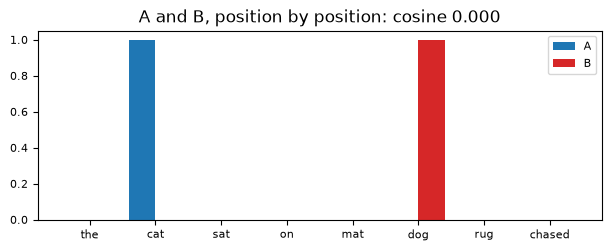

In [2]:
A = np.array([0, 1, 0, 0, 0, 0, 0, 0])  # cat
B = np.array([0, 0, 0, 0, 0, 1, 0, 0])  # dog
compare(A, B)

### Solution

In [3]:
cat, dog = np.eye(len(WORDS))[[WORDS.index("cat"), WORDS.index("dog")]]
c21 = cosine(np.array([2, 1]), np.array([1, 2]))
display(Markdown(f"Two different one-hot vectors never have a 1 in the same position, so `cat` and `dog` have dot product "
                 f"{cat @ dog:g} and cosine {cosine(cat, dog):g}, and every vector has cosine {cosine(cat, cat):g} with itself. "
                 f"`[2, 1]` and `[1, 2]` have numbers in both positions, and their cosine is {c21:.3f}, an angle of "
                 f"{np.degrees(np.arccos(c21)):.0f} degrees."))

Two different one-hot vectors never have a 1 in the same position, so `cat` and `dog` have dot product 0 and cosine 0, and every vector has cosine 1 with itself. `[2, 1]` and `[1, 2]` have numbers in both positions, and their cosine is 0.800, an angle of 37 degrees.

## 2. Neighbour rows

A neighbour row counts the words one position before and after each use of a
word. Over the columns `the`, `sat` and `chased`, `cat` has the row
`[2, 1, 1]`. Run the cell: is `dog` or `mat` closer to `cat`? Then add a
fourth sentence, `the dog chased the cat`: count the new rows of `cat` and
`dog`, type them into the cell, and run it again.

row of cat over the, sat, chased: (2, 1, 1)
row of dog over the, sat, chased: (2, 1, 0)
row of mat over the, sat, chased: (1, 0, 0)


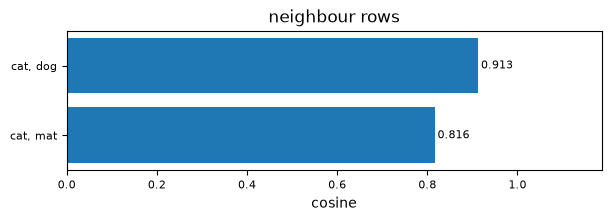

In [4]:
CAT = np.array([2, 1, 1])  # over the, sat, chased
DOG = np.array([2, 1, 0])
MAT = np.array([1, 0, 0])
rank(CAT, DOG, MAT)

### Solution

In [5]:
r = {w: count_row(w, SENTENCES) for w in ("cat", "dog", "mat")}
four = SENTENCES + ["the dog chased the cat"]
cat4, dog4 = count_row("cat", four), count_row("dog", four)
display(Markdown(f"Counted from the three sentences, `cat` is {fmt(r['cat'])}, `dog` {fmt(r['dog'])} and `mat` {fmt(r['mat'])}, "
                 f"so `dog` is closer to `cat`: {cosine(r['cat'], r['dog']):.3f} against {cosine(r['cat'], r['mat']):.3f}. "
                 f"With the fourth sentence both rows become {fmt(cat4)}, and their cosine is {cosine(cat4, dog4):.3f}."))

Counted from the three sentences, `cat` is (2, 1, 1), `dog` (2, 1, 0) and `mat` (1, 0, 0), so `dog` is closer to `cat`: 0.913 against 0.816. With the fourth sentence both rows become (3, 1, 1), and their cosine is 1.000.

## 3. One training step

Each word has two vectors, one as the centre word and one as a neighbour.
The score of a pair is their dot product, and σ of the score is the model's
probability that the pair is real. One training step adds `ETA` × (`TARGET`
− σ) × `U_CONTEXT` to `V_CAT`. Run the cell for the real pair `cat`, `sat`,
then set `ETA` to 1 and to 2. Then try the noise pair `cat`, `rug`: set
`U_CONTEXT` to `np.array([-1.0, -0.5, 1.0, -0.5])` and `TARGET` to 0. Does
the score rise or fall?

score 1.100, σ 0.750, target 1, error +0.250
V_CAT before: (0.600, 0.400, -0.200, 0.200), after: (0.700, 0.480, -0.250, 0.240)
score after the step 1.305, σ 0.787


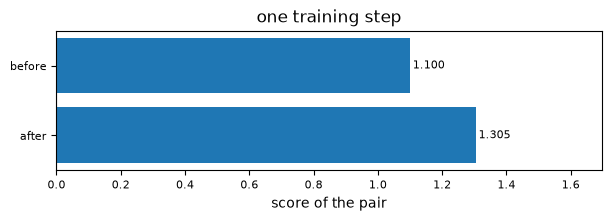

In [6]:
V_CAT = np.array([0.6, 0.4, -0.2, 0.2])
U_CONTEXT = np.array([1.0, 0.8, -0.5, 0.4])  # sat
ETA = 0.4
TARGET = 1
train_step(V_CAT, U_CONTEXT, ETA, TARGET)

### Solution

In [7]:
v, sat, rug = np.array([0.6, 0.4, -0.2, 0.2]), np.array([1.0, 0.8, -0.5, 0.4]), np.array([-1.0, -0.5, 1.0, -0.5])
real = {e: scores(v, sat, e, 1) for e in (0.4, 1, 2)}
s, s2, _ = scores(v, rug, 0.4, 0)
display(Markdown(f"For `cat`, `sat` the score rises from {real[0.4][0]:.3f} to {real[0.4][1]:.3f} at learning rate 0.4, to "
                 f"{real[1][1]:.3f} at 1 and to {real[2][1]:.3f} at 2, since the step grows with `ETA`. For the noise pair "
                 f"`cat`, `rug` the error is negative, so `V_CAT` moves away from the vector of `rug` and the score falls "
                 f"from {s:.3f} to {s2:.3f}."))

For `cat`, `sat` the score rises from 1.100 to 1.305 at learning rate 0.4, to 1.612 at 1 and to 2.124 at 2, since the step grows with `ETA`. For the noise pair `cat`, `rug` the error is negative, so `V_CAT` moves away from the vector of `rug` and the score falls from -1.100 to -1.350.

## Appendix. One vector for a word with two senses

The cosine of two vectors a and b is their dot product over their two
lengths:

cos(a, b) = a · b / (‖a‖ ‖b‖).

One training step for a pair with centre vector v and context vector u:

new v = v + ETA × (TARGET − σ(v · u)) × u, with σ(s) = 1 / (1 + e^(−s)).

A word used in two senses still gets one vector. Arora and colleagues found
that vector close to the sum of its sense vectors, each weighted by how often
the sense is used:

bank = MONEY_SHARE × money + (1 − MONEY_SHARE) × river.

With money in seven uses of ten, `bank` lies between the two senses, nearer
the money sense.

bank = 0.7 × money (1, 2) + 0.3 × river (5, 1) = (2.20, 1.70)


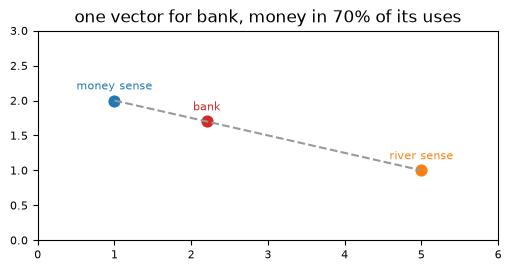

In [8]:
place_bank(0.7)

**Exercise.** Set `MONEY_SHARE` to 0.5 and then to 0.9, and rerun the cell.
Where does `bank` go each time, and which share would put it on the river
sense?

bank = 0.7 × money (1, 2) + 0.3 × river (5, 1) = (2.20, 1.70)


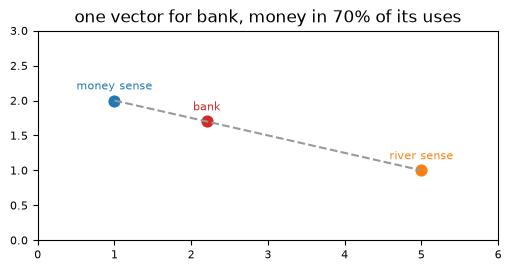

In [9]:
MONEY_SHARE = 0.7
place_bank(MONEY_SHARE)

### Solution

In [10]:
spots = "; ".join(f"at {x:g}, ({p[0]:.1f}, {p[1]:.1f})" for x in (0.5, 0.7, 0.9) for p in [x * MONEY + (1 - x) * RIVER])
display(Markdown(f"`bank` lies on the line between the two sense points, nearer the money sense the larger `MONEY_SHARE` is: {spots}. "
                 f"Only a share of {0:g} puts it on the river sense, and only a share of {1:g} on the money sense."))

`bank` lies on the line between the two sense points, nearer the money sense the larger `MONEY_SHARE` is: at 0.5, (3.0, 1.5); at 0.7, (2.2, 1.7); at 0.9, (1.4, 1.9). Only a share of 0 puts it on the river sense, and only a share of 1 on the money sense.